# Trees-Ensemble Methods

In [46]:
# --- 1. CORE DATA & VIZ ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
%matplotlib inline

# --- 2. STATSMODELS (Statistical Inference & Formulas) ---
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.formula.api import ols
from statsmodels.stats.outliers_influence import variance_inflation_factor as VIF
from statsmodels.stats.anova import anova_lm
from statsmodels.nonparametric.smoothers_lowess import lowess

# --- 3. SKLEARN: PREPROCESSING & DATA PIPELINES ---
from sklearn.model_selection import (
    train_test_split, LeaveOneOut, KFold, 
    cross_val_score, GridSearchCV, RandomizedSearchCV)

from sklearn.preprocessing import (
    StandardScaler, MinMaxScaler, PolynomialFeatures, OneHotEncoder)

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

# --- 4. SKLEARN: LINEAR MODELS (Chapter 3, 4, & 6) ---
from sklearn.linear_model import (
    LinearRegression, LogisticRegression, 
    Ridge, Lasso, ElasticNet, RidgeCV, LassoCV)

# --- 5. SKLEARN: MODEL SELECTION & DIMENSIONALITY REDUCTION (Chapter 6) ---
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.decomposition import PCA
from sklearn.cross_decomposition import PLSRegression

# --- 6. SKLEARN: TREE-BASED MODELS & ENSEMBLES (Chapter 8) ---
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier, plot_tree
from sklearn.ensemble import (
    RandomForestRegressor, RandomForestClassifier,
    GradientBoostingRegressor, GradientBoostingClassifier, HistGradientBoostingClassifier,
    BaggingRegressor, BaggingClassifier, AdaBoostRegressor)

# --- 7. SKLEARN: SUPPORT VECTOR MACHINES (Chapter 9) ---
from sklearn.svm import SVC, SVR

# --- 8. SKLEARN: NEAREST NEIGHBORS & CLUSTERING (Chapter 4 & 12) ---
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.cluster import KMeans, AgglomerativeClustering

# --- 9. SKLEARN: EVALUATION METRICS ---
from sklearn.metrics import (
    mean_squared_error, r2_score, mean_absolute_error, precision_score, recall_score, 
    f1_score, accuracy_score, confusion_matrix, ConfusionMatrixDisplay, classification_report, 
    roc_curve, auc, roc_auc_score, silhouette_score)

# --- 10. UTILS & RESAMPLING ---
from sklearn.utils import resample
import warnings
warnings.filterwarnings('ignore')
from patsy import (dmatrix, bs)

# 0. Common Setup

In [2]:
df = pd.read_csv("Heart.csv")

df["AHD"] = df["AHD"].map({
    "No": 0,
    "Yes": 1
})

X = df.drop(columns=["AHD"])
X = pd.get_dummies(X, drop_first=True)

y = df["AHD"]

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

# 1. Bagging

In [4]:
bag_model = BaggingClassifier(
    estimator=DecisionTreeClassifier(),
    n_estimators=500,
    random_state=42
)

bag_model.fit(X_train, y_train)

BaggingClassifier(estimator=DecisionTreeClassifier(), n_estimators=500,
                  random_state=42)

In [9]:
bag_pred = bag_model.predict(X_test)

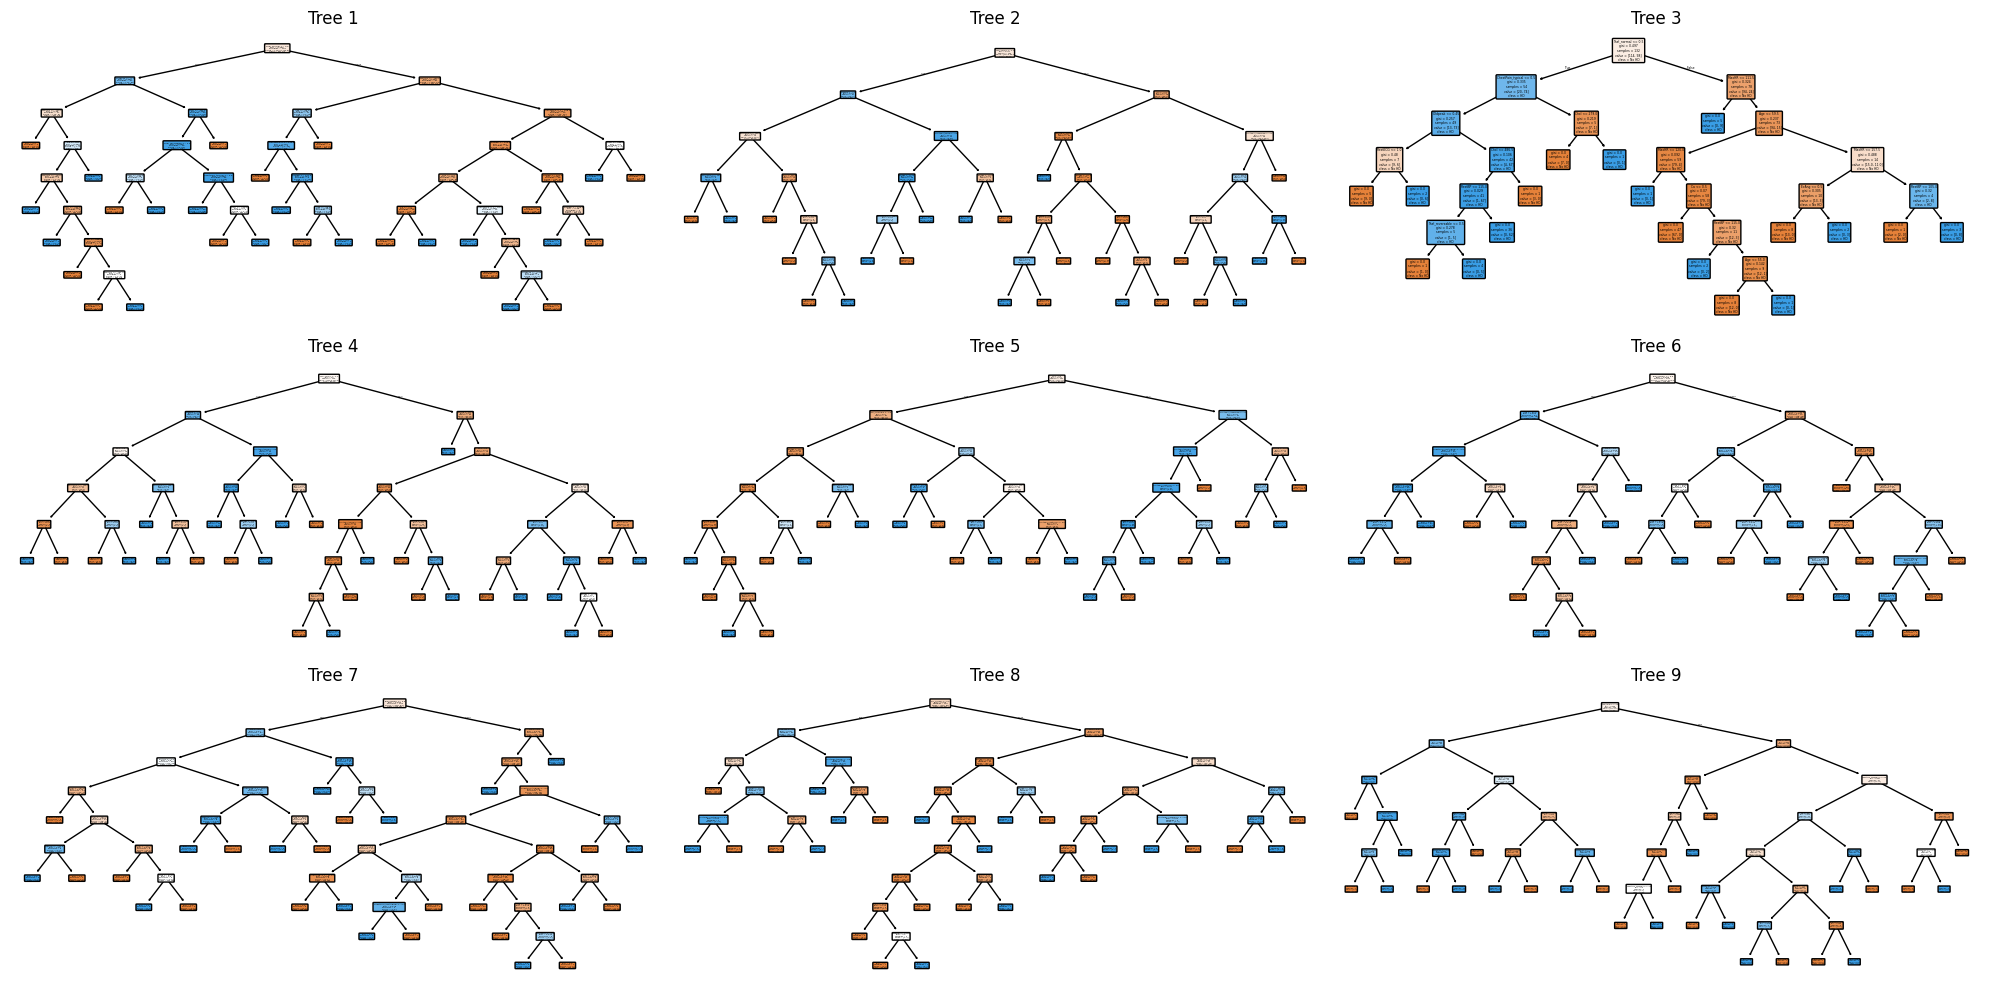

In [10]:
fig, axes = plt.subplots(3, 3, figsize=(20,10))

for i, ax in enumerate(axes.flatten()):

    plot_tree(
        bag_model.estimators_[i],
        feature_names=X.columns,
        class_names=["No HD", "HD"],
        filled=True,
        rounded=True,
        ax=ax
    )

    ax.set_title(f"Tree {i+1}")

plt.tight_layout()
plt.show()

<Figure size 400x400 with 0 Axes>

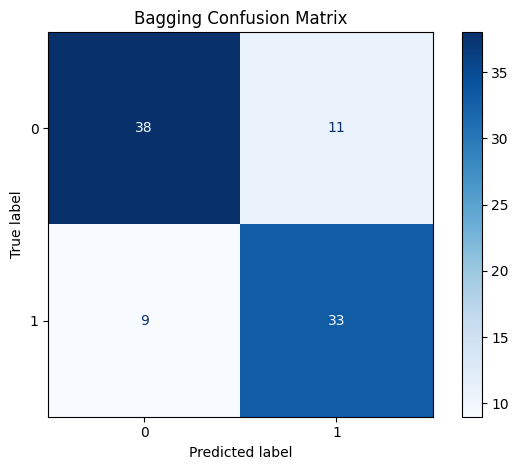

In [11]:
plt.figure(figsize=(4,4))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    bag_pred,
    cmap="Blues"
)

plt.title("Bagging Confusion Matrix")
plt.tight_layout()
plt.show()

In [23]:
bg_report = classification_report(
    y_test,
    bag_pred,
    output_dict=True
)

bg_report_df = pd.DataFrame(report).transpose()

bg_report_df

,precision,recall,f1-score,support
0,0.847826,0.795918,0.821053,49.000000
1,0.777778,0.833333,0.804598,42.000000
accuracy,0.813187,0.813187,0.813187,0.813187
macro avg,0.812802,0.814626,0.812825,91.000000
weighted avg,0.815496,0.813187,0.813458,91.000000


### Interpretation of Classification Metrics — Bagging Classifier

The bagging classifier achieved an overall accuracy of:

$$
Accuracy = 0.780
$$

meaning that approximately 78% of patients in the test set were correctly classified as either having or not having heart disease.

---

### Class 0 — No Heart Disease

#### Precision

$$
Precision_0 = 0.809
$$

Among patients predicted to *not* have heart disease, approximately 80.9% truly did not have heart disease.

This measures the reliability of negative predictions.

#### Recall

$$
Recall_0 = 0.776
$$

Among patients who truly did not have heart disease, approximately 77.6% were correctly identified by the model.

This measures how effectively the classifier detects healthy patients.

---

#### F1-score

$$
F1_0 = 0.792
$$

The F1-score combines precision and recall into a single metric through the harmonic mean. The value of 0.792 indicates relatively balanced performance for the healthy class.

---

### Class 1 — Heart Disease

#### Precision

$$
Precision_1 = 0.750
$$

Among patients predicted to have heart disease, approximately 75.0% truly had heart disease.

Thus, around 25% of positive predictions correspond to false positives.

#### Recall (Sensitivity)

$$
Recall_1 = 0.786
$$

Among patients who truly had heart disease, approximately 78.6% were correctly identified.

This metric is particularly important in medical diagnostics because low recall would imply failing to detect diseased patients (false negatives).

#### F1-score

$$
F1_1 = 0.767
$$

The F1-score indicates a reasonably balanced trade-off between precision and recall for heart disease detection.

---

### Macro Average

$$
Macro\ Avg \approx 0.779
$$

The macro average computes the unweighted mean across both classes, treating healthy and diseased patients equally regardless of class frequency.

Because the dataset is relatively balanced, the macro average is close to the weighted average.

### Weighted Average

$$
Weighted\ Avg \approx 0.781
$$

The weighted average accounts for class frequencies when averaging performance metrics.

Since the two classes contain a similar number of observations:
- No HD: 49 patients
- HD: 42 patients

the weighted and macro averages are very similar.

---

### Overall Interpretation

The bagging classifier demonstrates reasonably balanced classification performance across both classes.

The model appears slightly stronger at identifying healthy patients (higher precision for class 0), while still maintaining acceptable sensitivity for detecting heart disease.

From a medical perspective, the recall for heart disease:

$$
Recall_1 = 0.786
$$

is particularly important because it indicates that the model successfully detects approximately 79% of diseased patients.

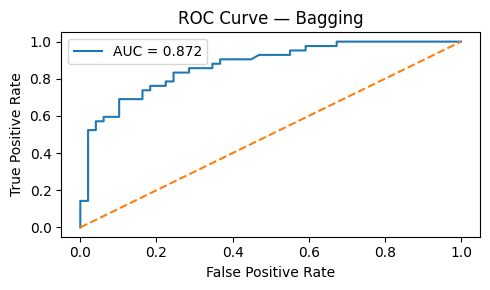

In [72]:
bag_probs = bag_model.predict_proba(X_test)[:,1]

fpr, tpr, thresholds = roc_curve(
    y_test,
    bag_probs
)

roc_auc = auc(fpr, tpr)

plt.figure(figsize=(5,3))

plt.plot(
    fpr,
    tpr,
    label=f"AUC = {roc_auc:.3f}"
)

plt.plot(
    [0,1],
    [0,1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Bagging")
plt.legend()
plt.tight_layout()
plt.show()

### Interpretation of the ROC Curve

The ROC curve evaluates the classifier’s ability to distinguish between:
- patients with heart disease
- patients without heart disease

across all possible probability thresholds.

#### X-axis — False Positive Rate

$$
FPR = \frac{FP}{FP+TN}
$$

Represents:
- proportion of healthy patients incorrectly classified as diseased.

Moving right on the graph means:
- more false alarms.

#### Y-axis — True Positive Rate (Sensitivity)

$$
TPR = \frac{TP}{TP+FN}
$$

Represents:
- proportion of diseased patients correctly detected.

Moving upward means:
- better disease detection.


### Threshold Interpretation

The classifier outputs probabilities such as:

| Patient | Predicted Probability |
|---|---|
| A | 0.92 |
| B | 0.71 |
| C | 0.38 |

A classification threshold converts probabilities into class predictions.

Example:
- threshold = 0.5
- predict disease if:
  
$$
P(\text{HD}) > 0.5
$$

The ROC curve evaluates:
- ALL thresholds simultaneously.

### Shape Interpretation

A strong classifier produces a curve that:
- rises steeply upward
- stays near the top-left corner.

Why?

Because:
- high sensitivity is achieved
- while keeping false positives low.

### Diagonal Line

The dashed diagonal represents:

$$
TPR = FPR
$$

This corresponds to:
- random guessing.

A classifier near this line has little predictive value.

---

### Area Under the Curve (AUC)

The AUC summarises overall discrimination quality.

Interpretation:

| AUC | Interpretation |
|---|---|
| 0.5 | Random guessing |
| 0.6–0.7 | Weak |
| 0.7–0.8 | Acceptable |
| 0.8–0.9 | Strong |
| >0.9 | Excellent |

---

### Interpretation for the Heart Dataset

In the context of heart disease classification:
- high sensitivity is especially important
- missing diseased patients can be clinically dangerous.

Therefore, a curve substantially above the diagonal indicates that the bagging classifier is able to distinguish reasonably well between:
- healthy patients
- diseased patients

across many classification thresholds.

The ROC curve therefore provides a richer evaluation than accuracy alone because it explicitly visualises the trade-off between:
- disease detection
- false positive errors.

# 2. Random Forests

In [53]:
rf_model = RandomForestClassifier(
    n_estimators=500,
    max_features="sqrt",
    random_state=42
)

rf_model.fit(X_train, y_train)
rf_model

RandomForestClassifier(n_estimators=500, random_state=42)

In [54]:
rf_pred = rf_model.predict(X_test)

In [55]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance

,Feature,Importance
15,Thal_normal,0.112521
7,MaxHR,0.109284
11,Ca,0.104559
9,Oldpeak,0.095929
16,Thal_reversable,0.090653
1,Age,0.082891
4,Chol,0.072946
0,Unnamed: 0,0.070054
3,RestBP,0.062998
8,ExAng,0.048101


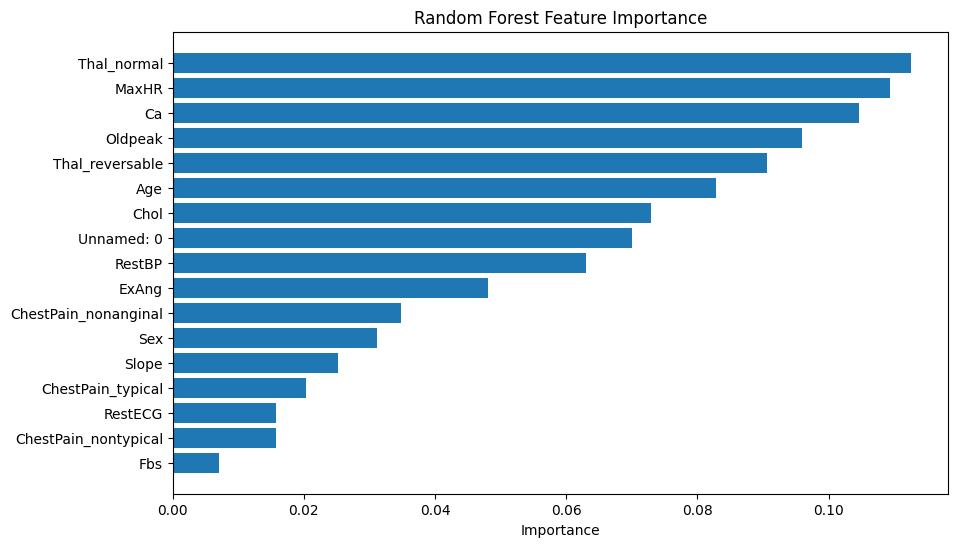

In [56]:
plt.figure(figsize=(10,6))

plt.barh(
    importance["Feature"],
    importance["Importance"]
)

plt.gca().invert_yaxis()

plt.xlabel("Importance")
plt.title("Random Forest Feature Importance")

plt.show()

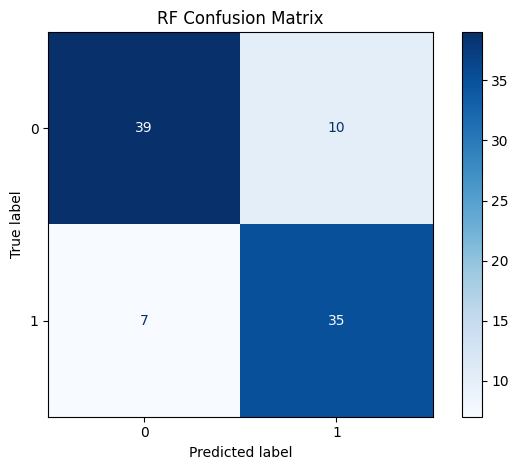

In [57]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    rf_pred,
    cmap="Blues"
)

plt.title("RF Confusion Matrix")
plt.tight_layout()
plt.show()

In [58]:
rf_report = classification_report(
    y_test,
    rf_pred,
    output_dict=True
)

rf_report_df = pd.DataFrame(report).transpose()

rf_report_df

,precision,recall,f1-score,support
0,0.847826,0.795918,0.821053,49.000000
1,0.777778,0.833333,0.804598,42.000000
accuracy,0.813187,0.813187,0.813187,0.813187
macro avg,0.812802,0.814626,0.812825,91.000000
weighted avg,0.815496,0.813187,0.813458,91.000000


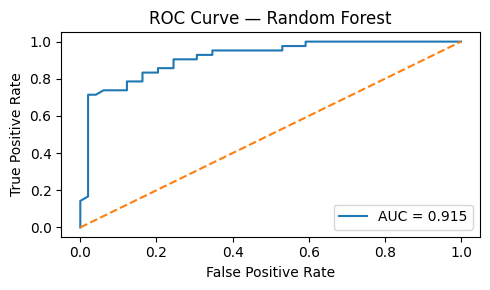

In [70]:
rf_probs = rf_model.predict_proba(X_test)[:,1]

fpr, tpr, thresholds = roc_curve(
    y_test,
    rf_probs
)

roc_auc = auc(fpr, tpr)

plt.figure(figsize=(5,3))

plt.plot(
    fpr,
    tpr,
    label=f"AUC = {roc_auc:.3f}"
)

plt.plot(
    [0,1],
    [0,1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Random Forest")
plt.legend()
plt.tight_layout()
plt.show()

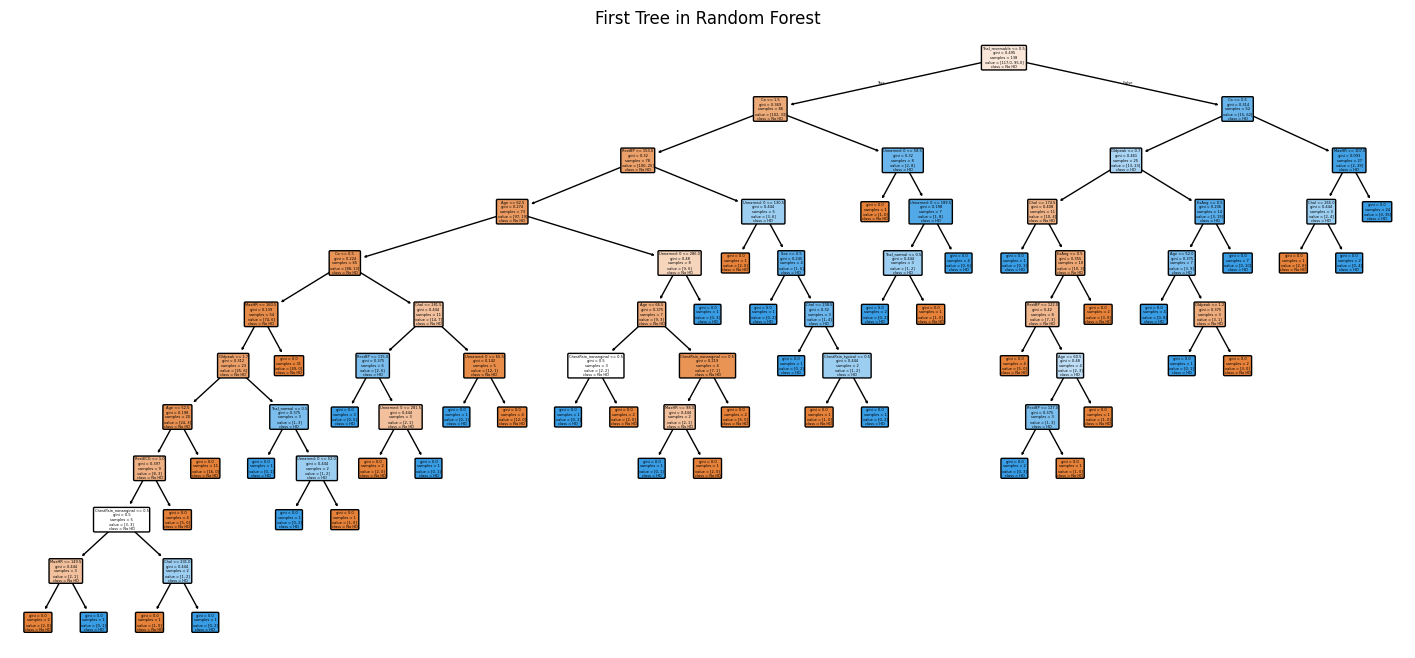

In [60]:
plt.figure(figsize=(18,8))

plot_tree(
    rf_model.estimators_[0],
    feature_names=X.columns,
    class_names=["No HD", "HD"],
    filled=True,
    rounded=True
)

plt.title("First Tree in Random Forest")

plt.show()

# 3. Boosting

In [61]:
boost_model = HistGradientBoostingClassifier(
    learning_rate=0.01,
    max_depth=2,
    random_state=42
)

boost_model.fit(X_train, y_train)
boost_model

HistGradientBoostingClassifier(learning_rate=0.01, max_depth=2, random_state=42)

In [62]:
boost_pred = boost_model.predict(X_test)

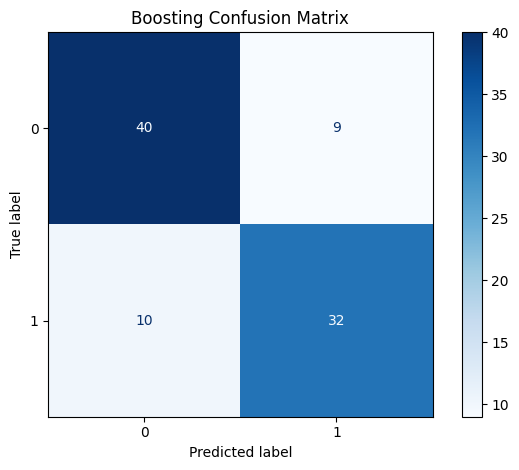

In [63]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    boost_pred,
    cmap="Blues"
)

plt.title("Boosting Confusion Matrix")
plt.tight_layout()
plt.show()

In [64]:
boost_report = classification_report(
    y_test,
    boost_pred,
    output_dict=True
)

boost_report_df = pd.DataFrame(report).transpose()

boost_report_df

,precision,recall,f1-score,support
0,0.847826,0.795918,0.821053,49.000000
1,0.777778,0.833333,0.804598,42.000000
accuracy,0.813187,0.813187,0.813187,0.813187
macro avg,0.812802,0.814626,0.812825,91.000000
weighted avg,0.815496,0.813187,0.813458,91.000000


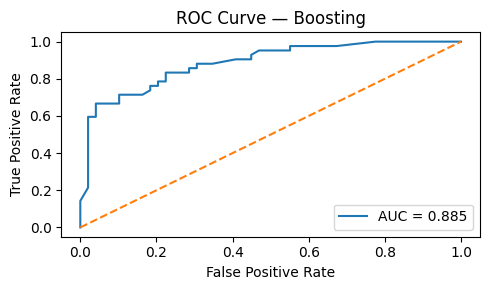

In [71]:
boost_probs = boost_model.predict_proba(X_test)[:,1]

fpr, tpr, thresholds = roc_curve(
    y_test,
    boost_probs
)

roc_auc = auc(fpr, tpr)

plt.figure(figsize=(5,3))

plt.plot(
    fpr,
    tpr,
    label=f"AUC = {roc_auc:.3f}"
)

plt.plot(
    [0,1],
    [0,1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Boosting")
plt.legend()
plt.tight_layout()
plt.show()

# Model Comparison

In [66]:
comparison = pd.DataFrame({

    "Model": [
        "Bagging",
        "Random Forest",
        "Boosting"
    ],

    "Accuracy": [
        accuracy_score(y_test, bag_pred),
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test, boost_pred)
    ],

    "Precision": [
        precision_score(y_test, bag_pred),
        precision_score(y_test, rf_pred),
        precision_score(y_test, boost_pred)
    ],

    "Recall": [
        recall_score(y_test, bag_pred),
        recall_score(y_test, rf_pred),
        recall_score(y_test, boost_pred)
    ],

    "F1": [
        f1_score(y_test, bag_pred),
        f1_score(y_test, rf_pred),
        f1_score(y_test, boost_pred)
    ],

    "AUC": [
        roc_auc_score(y_test, bag_probs),
        roc_auc_score(y_test, rf_probs),
        roc_auc_score(y_test, boost_probs)
    ]
})

comparison

,Model,Accuracy,Precision,Recall,F1,AUC
0,Bagging,0.780220,0.750000,0.785714,0.767442,0.871963
1,Random Forest,0.813187,0.777778,0.833333,0.804598,0.914966
2,Boosting,0.791209,0.780488,0.761905,0.771084,0.884597


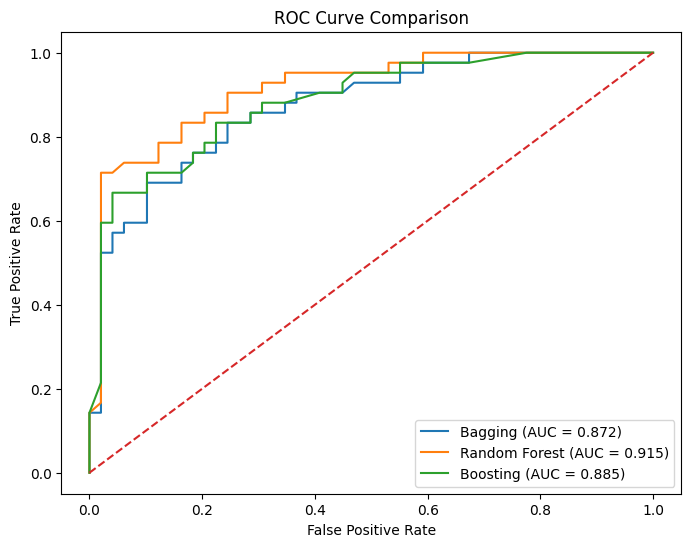

In [67]:
# Compute ROC curves
bag_fpr, bag_tpr, _ = roc_curve(y_test, bag_probs)
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_probs)
boost_fpr, boost_tpr, _ = roc_curve(y_test, boost_probs)

# Compute AUCs
bag_auc = auc(bag_fpr, bag_tpr)
rf_auc = auc(rf_fpr, rf_tpr)
boost_auc = auc(boost_fpr, boost_tpr)

# Plot
plt.figure(figsize=(8,6))

plt.plot(bag_fpr, bag_tpr,label=f"Bagging (AUC = {bag_auc:.3f})")

plt.plot(rf_fpr, rf_tpr, label=f"Random Forest (AUC = {rf_auc:.3f})")

plt.plot(boost_fpr, boost_tpr, label=f"Boosting (AUC = {boost_auc:.3f})")

# Random classifier reference
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

# Annex - Tree Based Models explained

This annex provides a structured comparison of the main tree-based ensemble methods: bagging, random forests, boosting, and BART (Bayesian Additive Regression Trees). The focus is on their learning mechanisms, statistical properties, and practical implications.

---

## 1. Bagging (Bootstrap Aggregating)

### Core idea
Bagging constructs multiple decision trees independently using bootstrap resampling of the training data, then aggregates their predictions.

### Procedure
- Draw $B$ bootstrap samples from the training set
- Fit a full decision tree to each sample
- Aggregate predictions:
  - Regression: average
  - Classification: majority vote

### Statistical effect
- Primarily reduces **variance**
- Does not meaningfully reduce **bias**

### Key characteristic
- Trees are typically highly correlated because they are trained on similar data structures

### Strengths
- Simple and stable improvement over a single tree
- Reduces overfitting relative to a single deep tree

### Limitations
- Limited variance reduction due to correlated trees

---

## 2. Random Forest (RF)

### Core idea
Random Forest improves bagging by introducing additional randomness in feature selection at each split.

### Procedure
- Bootstrap sampling (as in bagging)
- At each split, consider only a random subset of predictors
- Aggregate predictions across trees

### Statistical effect
- Strong reduction in **variance**
- Slight increase in bias (typically negligible in practice)

### Key characteristic
- Decorrelates trees by limiting split-level feature access

### Strengths
- Robust, high-performing default model for tabular data
- Built-in feature importance measures

### Limitations
- Still not highly interpretable
- Limited extrapolation ability

---

## 3. Boosting

### Core idea
Boosting builds trees sequentially, where each tree corrects the errors of the current ensemble.

### Procedure (conceptual)
- Fit an initial weak tree
- Compute residual errors
- Fit subsequent trees to residuals
- Combine models as a weighted sum:
$$
f(x) = \sum_{m=1}^{M} \lambda \, T_m(x)
$$

### Statistical effect
- Strong reduction in **bias**
- Can reduce variance, but may overfit without regularisation

### Key characteristics
- Sequential dependence (non-parallel training)
- Focus on hard-to-predict observations

### Strengths
- Very high predictive accuracy on structured/tabular data
- Flexible function approximation

### Limitations
- Sensitive to hyperparameters
- Higher risk of overfitting compared to RF

---

## 4. BART (Bayesian Additive Regression Trees)

### Core idea
BART models the response as a sum of many small trees within a Bayesian framework.

### Model form
$$
y = \sum_{m=1}^{M} g_m(x) + \epsilon
$$

where each $g_m(x)$ is a small decision tree drawn from a prior.

### Procedure
- Specify priors over tree structures and leaf values
- Use MCMC to sample from the posterior distribution
- Aggregate predictions across sampled trees

### Statistical effect
- Simultaneously controls **bias and variance**
- Regularisation is induced via Bayesian priors

### Key characteristics
- Fully probabilistic model
- Produces posterior predictive distributions

### Strengths
- Provides uncertainty quantification
- Strong regularisation and stability
- Theoretically principled Bayesian framework

### Limitations
- Computationally intensive
- Less commonly used in industrial ML pipelines

---

## Comparative Summary

| Method          | Training Style | Main Objective       | Bias     | Variance | Tree Correlation | Interpretability | Key Strength |
|----------------|----------------|---------------------|----------|----------|------------------|------------------|--------------|
| Bagging        | Parallel       | Reduce variance     | Unchanged | ↓        | High             | Medium           | Simple variance reduction |
| Random Forest  | Parallel       | Reduce variance     | Slight ↑  | ↓↓       | Lower            | Medium           | Strong general-purpose model |
| Boosting       | Sequential     | Reduce bias         | ↓↓       | Mixed    | Not independent  | Low              | High predictive accuracy |
| BART           | Bayesian       | Full inference      | ↓↓       | ↓↓       | Controlled       | Medium-high      | Uncertainty quantification |

---

## Conceptual Unification

These methods can be understood along two axes:

### 1. Independence vs Dependence
- Bagging / Random Forest: independent models
- Boosting: dependent sequential corrections
- BART: dependent but probabilistically regularised

### 2. Bias–Variance Strategy
- Bagging / RF: variance reduction
- Boosting: bias reduction
- BART: joint bias–variance control via Bayesian priors

---

## Practical Guidance

- **Random Forest**: strong default for tabular prediction tasks
- **Boosting**: best predictive performance with tuning (e.g., gradient boosting frameworks)
- **Bagging**: baseline variance reduction, conceptually important
- **BART**: preferred when uncertainty quantification is required or Bayesian inference is desired